In [59]:
pip install yfinance

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim

In [61]:
device=torch.device('cuda'if torch.cuda.is_available() else 'cpu')

In [62]:
ticker='AMZN'
df=yf.download(ticker,'2020-01-01')

/tmp/ipykernel_467/171571966.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,'2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [63]:
df

Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,
2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,95.550003,94.321999,94.902000,70160000
...,...,...,...,...,...
2026-03-09,213.490005,213.820007,207.110001,210.449997,54642900
2026-03-10,214.330002,215.649994,212.429993,214.190002,35678800


<Axes: xlabel='Date'>

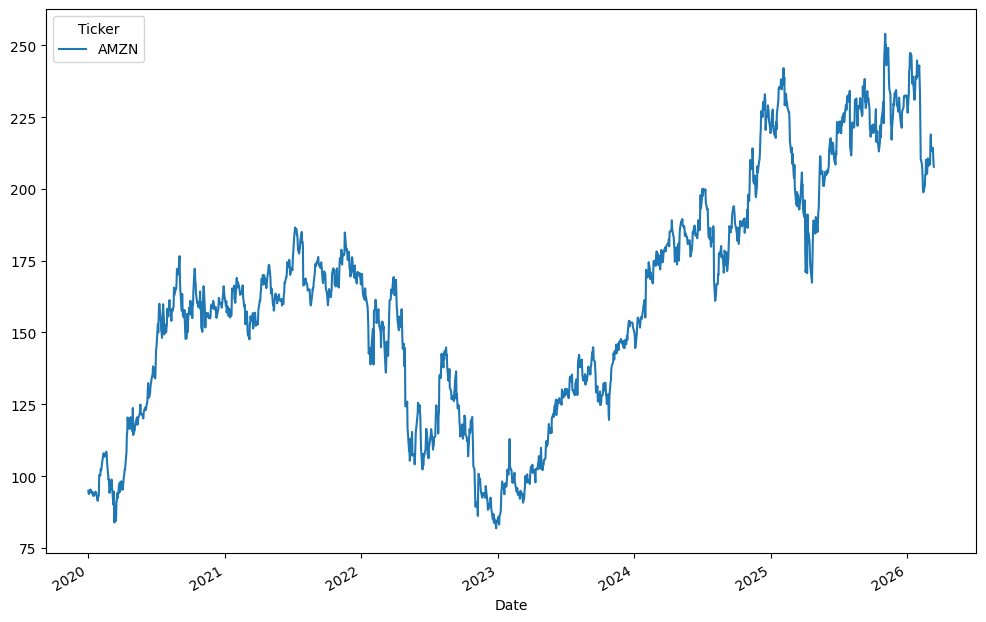

In [64]:
df.Close.plot(figsize=(12,8))

In [65]:
scaler=StandardScaler()
df['Close']=scaler.fit_transform(df[['Close']])


In [66]:
df.Close

Ticker,AMZN
Date,
2020-01-02,-1.599116
2020-01-03,-1.627193
2020-01-06,-1.593182
2020-01-07,-1.588331
2020-01-08,-1.606476
...,...
2026-03-09,1.291165
2026-03-10,1.311637
2026-03-11,1.270692


In [67]:
seq_length=30
data=[]

for i in range(len(df)-seq_length):
    data.append(df.Close[i:i+seq_length])

data=np.array(data)
train_size=int(0.8*len(data))

X_train=torch.from_numpy(data[:train_size,:-1,:])

In [68]:
data

array([[[-1.59911617],
        [-1.62719289],
        [-1.59318156],
        ...,
        [-1.29106434],
        [-1.27985318],
        [-1.29219767]],

       [[-1.62719289],
        [-1.59318156],
        [-1.58833138],
        ...,
        [-1.27985318],
        [-1.29219767],
        [-1.31047678]],

       [[-1.59318156],
        [-1.58833138],
        [-1.60647642],
        ...,
        [-1.29219767],
        [-1.31047678],
        [-1.28512973]],

       ...,

       [[ 2.05133163],
        [ 2.01063019],
        [ 1.97943387],
        ...,
        [ 1.28434052],
        [ 1.29116469],
        [ 1.3116372 ]],

       [[ 2.01063019],
        [ 1.97943387],
        [ 1.92020973],
        ...,
        [ 1.29116469],
        [ 1.3116372 ],
        [ 1.27069181]],

       [[ 1.97943387],
        [ 1.92020973],
        [ 2.00941188],
        ...,
        [ 1.3116372 ],
        [ 1.27069181],
        [ 1.19465083]]])

In [69]:
train_size=int(0.8*len(data))
X_train=torch.from_numpy(data[:train_size,:-1,:]).type(torch.Tensor).to(device)
y_train=torch.from_numpy(data[:train_size,-1,:]).type(torch.Tensor).to(device)

X_test=torch.from_numpy(data[train_size:,:-1,:]).type(torch.Tensor).to(device)
y_test=torch.from_numpy(data[train_size:,-1,:]).type(torch.Tensor).to(device)

In [70]:
class predictionModel(nn.Module):
  def __init__(self,input_dim,hidden_dim,num_layers,output_dim):
    super(predictionModel,self).__init__()

    self.num_layers=num_layers
    self.hidden_dim=hidden_dim
    self.lstm=nn.LSTM(input_dim,hidden_dim,num_layers,batch_first=True)
    self.fc=nn.Linear(hidden_dim,output_dim)

  def forward(self,x):
    h0=torch.zeros(self.num_layers,x.size(0),self.hidden_dim).to(device)
    c0=torch.zeros(self.num_layers,x.size(0),self.hidden_dim).to(device)
    out,(hn,cn)=self.lstm(x, (h0.detach(),c0.detach()))
    out=self.fc(out[:,-1,:])

    return out

In [71]:
model=predictionModel(input_dim=1,hidden_dim=32,num_layers=2,output_dim=1).to(device)

In [72]:
criterian=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

num_epochs=200
for i in range(num_epochs):
  y_train_pred = model(X_train)

  loss=criterian(y_train_pred,y_train)
  if i % 25==0:
    print(i,loss)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


0 tensor(0.6665, grad_fn=<MseLossBackward0>)
25 tensor(0.0143, grad_fn=<MseLossBackward0>)
50 tensor(0.0096, grad_fn=<MseLossBackward0>)
75 tensor(0.0083, grad_fn=<MseLossBackward0>)
100 tensor(0.0075, grad_fn=<MseLossBackward0>)
125 tensor(0.0070, grad_fn=<MseLossBackward0>)
150 tensor(0.0066, grad_fn=<MseLossBackward0>)
175 tensor(0.0063, grad_fn=<MseLossBackward0>)


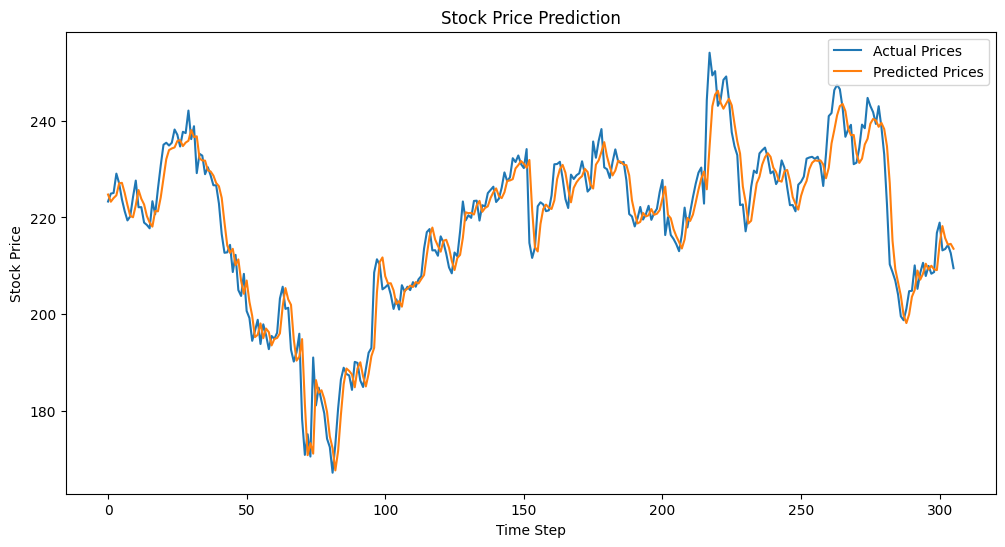

In [73]:
model.eval()
with torch.no_grad():
  y_test_pred = model(X_test)

y_test_pred_rescaled = scaler.inverse_transform(y_test_pred.cpu().numpy())
y_test_rescaled = scaler.inverse_transform(y_test.cpu().numpy())

# Visualize predictions
plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled, label='Actual Prices')
plt.plot(y_test_pred_rescaled, label='Predicted Prices')
plt.title('Stock Price Prediction')
plt.xlabel('Time Step')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [74]:
model.eval()
with torch.no_grad():
  y_test_pred = model(X_test)
y_train_pred_ = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.cpu().numpy())
y_test_pred_ = scaler.inverse_transform(y_test_pred.cpu().numpy())
y_test_ = scaler.inverse_transform(y_test.cpu().numpy())

In [75]:
train_rmse=root_mean_squared_error(y_train[:,0],y_train_pred_[:,0])
test_rmse=root_mean_squared_error(y_test[:,0],y_test_pred[:,0])


In [76]:
train_rmse


3.1921699047088623

In [77]:
test_rmse

0.11558103026702521

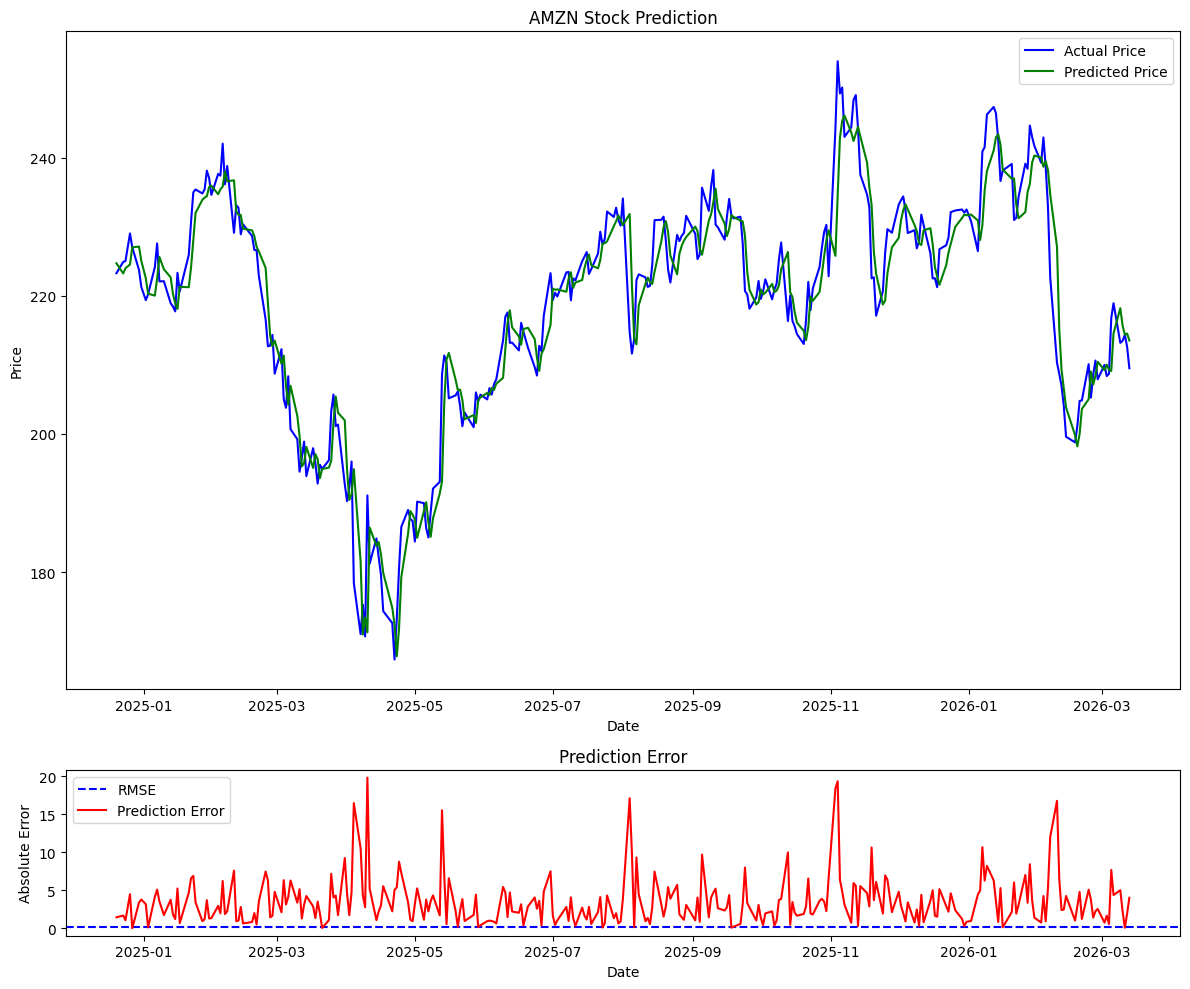

In [78]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12,10))
gs = gridspec.GridSpec(4, 1, figure=fig)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test_):].index, y_test_, color='blue', label='Actual Price')
ax1.plot(df.iloc[-len(y_test_):].index, y_test_pred_, color='green', label='Predicted Price')
ax1.legend()
ax1.set_title(f'{ticker} Stock Prediction')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price')

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color='blue', linestyle='--', label='RMSE')
ax2.plot(df.iloc[-len(y_test_):].index, abs(y_test_pred_ - y_test_), color='red', label='Prediction Error')
ax2.legend()
ax2.set_title('Prediction Error')
ax2.set_xlabel('Date')
ax2.set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()